In [1]:
# ============================================================
# Imports & Setup
# ============================================================
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.ticker import MaxNLocator

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Torch defaults
torch.set_default_dtype(torch.float32)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.current_device()} - {torch.cuda.get_device_name(0)}")

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Device in use: cuda
CUDA device: 0 - A100-PCIE-40GB


In [2]:
# ============================================================
# 1. Load SST Dataset
# ============================================================
sst_data = np.load("sst_normalized_5k.npy")

# Shape transformation to time-major: (time, spatial_points)
sst_time_major = sst_data.T
print("Original SST shape (time-major):", sst_time_major.shape)

# ============================================================
# 2. Time Setup & Data Splits
# ============================================================
dt = 1.0
warmup    = 100.0
traintime = 3900.0
valtime   = 500.0
testtime  = 500.0

maxtime = warmup + traintime + valtime + testtime

warmup_pts    = int(round(warmup / dt))
traintime_pts = int(round(traintime / dt))
valtime_pts   = int(round(valtime / dt))
testtime_pts  = int(round(testtime / dt))

warmtrain_pts = warmup_pts + traintime_pts
val_end       = warmtrain_pts + valtime_pts
maxtime_pts   = int(round(maxtime / dt))

print("\n==== Data Splits ====")
print(f"Warmup : {warmup_pts}")
print(f"Train  : {traintime_pts}")
print(f"Val    : {valtime_pts}")
print(f"Test   : {testtime_pts}")

Original SST shape (time-major): (5001, 2801)

==== Data Splits ====
Warmup : 100
Train  : 3900
Val    : 500
Test   : 500


In [3]:
# ============================================================
# 3. Fit PCA/SVD on TRAINING DATA ONLY
# ============================================================
pca_train_end = warmtrain_pts
n_components = 1

train_sst = sst_time_major[:pca_train_end]

pca = PCA(n_components=n_components, svd_solver='full')
pca.fit(train_sst)

# Transform entire dataset using TRAIN PCA basis
sst_pca = pca.transform(sst_time_major)
explained_variance = pca.explained_variance_ratio_

print("\n==== PCA/SVD Summary ====")
print(f"Retained components      : {n_components}")
print(f"Explained variance ratio : {explained_variance}")

# ============================================================
# 4. Prepare Latent SST Dataset
# ============================================================
latent_sst = sst_pca.T
X_soln = latent_sst[:, :maxtime_pts + 1]
d, T_full = X_soln.shape

print(f"\nLatent SST shape: {X_soln.shape}")


==== PCA/SVD Summary ====
Retained components      : 1
Explained variance ratio : [0.96191511]

Latent SST shape: (1, 5001)


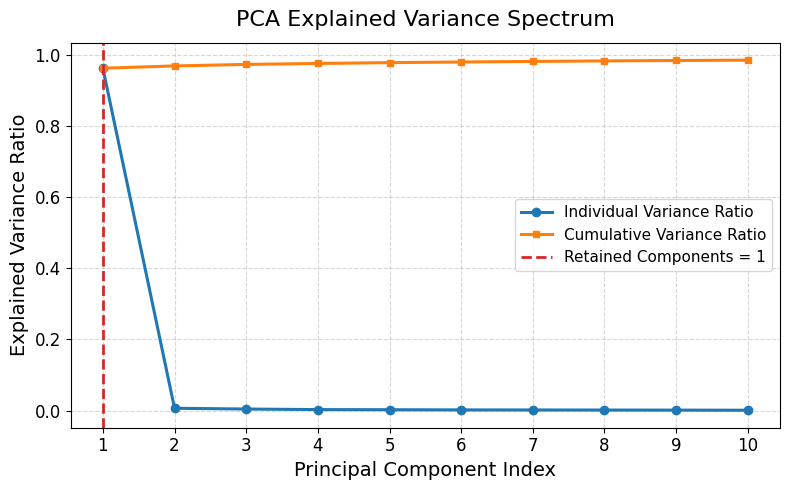

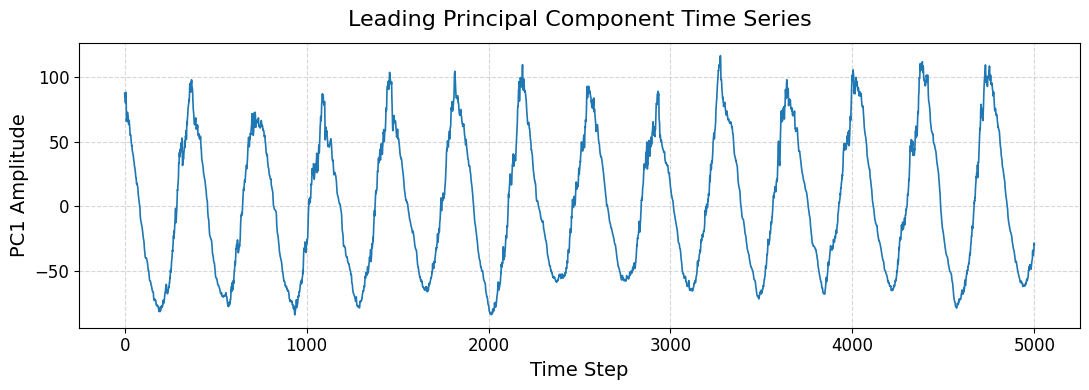

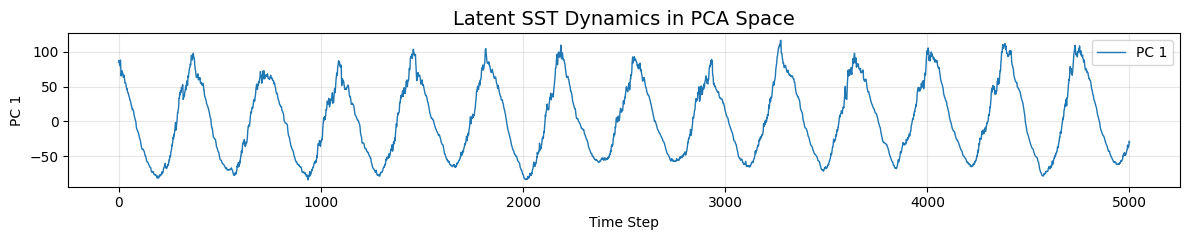


==== PCA Visualization Summary ====

PC01 Variance Ratio: 0.961915
PC02 Variance Ratio: 0.006428
PC03 Variance Ratio: 0.004244
PC04 Variance Ratio: 0.002666
PC05 Variance Ratio: 0.002315
PC06 Variance Ratio: 0.001803
PC07 Variance Ratio: 0.001635
PC08 Variance Ratio: 0.001427
PC09 Variance Ratio: 0.001166
PC10 Variance Ratio: 0.000927

Cumulative Variance (first 10 PCs): 0.984526


In [4]:
# ============================================================
# Professional PCA / EOF Visualization
# ============================================================

# Refit with more components for diagnostic spectrum plotting
n_plot_components = 10
pca_plot = PCA(n_components=n_plot_components, svd_solver='full')
pca_plot.fit(train_sst)

explained_variance_plot = pca_plot.explained_variance_ratio_
cumulative_variance_plot = np.cumsum(explained_variance_plot)

# ------------------------------------------------------------
# Figure 1: Explained Variance Spectrum
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
components = np.arange(1, n_plot_components + 1)

# Variance plots
ax.plot(components, explained_variance_plot, marker='o', linewidth=2.2, markersize=6, label='Individual Variance Ratio')
ax.plot(components, cumulative_variance_plot, marker='s', linewidth=2.2, markersize=5, label='Cumulative Variance Ratio')

# Highlight retained dimensions
ax.axvline(x=n_components, linestyle='--', linewidth=2, color='tab:red', label=f'Retained Components = {n_components}')

# Axis Formatting
ax.set_xlabel('Principal Component Index', fontsize=14)
ax.set_ylabel('Explained Variance Ratio', fontsize=14)
ax.set_title('PCA Explained Variance Spectrum', fontsize=16, pad=12)
ax.set_xticks(components)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig('pca_explained_variance_professional.png', dpi=600, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Figure 2: Leading Principal Component Time Series
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
time_axis = np.arange(X_soln.shape[1])

ax.plot(time_axis, X_soln[0], linewidth=1.2, color='tab:blue')

# Axis Formatting
ax.set_xlabel('Time Step', fontsize=14)
ax.set_ylabel('PC1 Amplitude', fontsize=14)
ax.set_title('Leading Principal Component Time Series', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('pc1_timeseries_professional.png', dpi=600, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Figure 3: Latent SST Dynamics Overview
# ------------------------------------------------------------
num_components_to_plot = min(n_components, 10)
time_steps = np.arange(latent_sst.shape[1])

plt.figure(figsize=(12, 2.5 * num_components_to_plot))

for i in range(num_components_to_plot):
    plt.subplot(num_components_to_plot, 1, i + 1)
    plt.plot(time_steps, latent_sst[i], linewidth=1.0, label=f'PC {i+1}')
    plt.ylabel(f'PC {i+1}')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')

    if i == 0:
        plt.title("Latent SST Dynamics in PCA Space", fontsize=14)
    if i == num_components_to_plot - 1:
        plt.xlabel("Time Step")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Variance Summary Output
# ------------------------------------------------------------
print("\n==== PCA Visualization Summary ====\n")
for i, var in enumerate(explained_variance_plot):
    print(f"PC{i+1:02d} Variance Ratio: {var:.6f}")

print(f"\nCumulative Variance (first {n_plot_components} PCs): {cumulative_variance_plot[-1]:.6f}")

In [5]:
# ============================================================
# Dataset Splits & Setup
# ============================================================
X_noisy_dataset = X_soln.T
X = torch.tensor(X_noisy_dataset, dtype=torch.float32)       # noisy input
X_true = torch.tensor(X_noisy_dataset, dtype=torch.float32)  # clean reference

# Dataset splits
warmup_len, train_len, val_len, test_len = 100, 3900, 500, 500

X_warmup = X[:warmup_len].to(device)
X_train_clean = X[warmup_len:warmup_len + train_len]
X_val  = X[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test = X[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)

# Ground truth references
X_val_true  = X_true[warmup_len + train_len : warmup_len + train_len + val_len].to(device)
X_test_true = X_true[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len].to(device)
X_val_true_raw = X_true[warmup_len + train_len : warmup_len + train_len + val_len]
X_test_true_raw = sst_time_major[warmup_len + train_len + val_len : warmup_len + train_len + val_len + test_len]

# Training-time noise (regularization for noise-free case: train_noise_scale = 0.0)
train_noise_scale = 0.0
signal_std = X_train_clean.std(dim=0, keepdim=True).cpu().numpy()
train_noise = np.random.normal(0.0, train_noise_scale * signal_std, X_train_clean.shape)
X_train = torch.tensor((X_train_clean.cpu().numpy() + train_noise).astype(np.float32), device=device)


# ============================================================
# Adaptive NVAR Model Definition
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class AdaptiveNVARModel(nn.Module):
    def __init__(self, dk, m, d, hidden_dim):
        super().__init__()
        self.mlp = FeatureMLP(dk, hidden_dim, m)
        self.readout = nn.Linear(dk + m, d, bias=False)

    def forward(self, H_lin):
        H_nn = self.mlp(H_lin)
        H_total = torch.cat([H_lin, H_nn], dim=1)
        return self.readout(H_total)


# ============================================================
# Helper Functions & Model Training
# ============================================================
def construct_H_lin(X, k):
    """Constructs delay-embedded features from time series."""
    T = X.shape[0]
    return torch.cat([X[i:T - k + i] for i in range(k)], dim=1)


def init_weights_stable(m):
    """Stable Xavier initialization for linear layers."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
        with torch.no_grad():
            m.weight.mul_(1.0)


def train_joint_model(
    X, k, m, hidden_dim=200,
    lr_adam=1e-4,
    max_epochs_adam=5000,
    save_path="best_joint_model.pth",
    adam_patience=200,
    tolerance=1e-8,
    device=None
):
    """Train Adaptive NVAR model using Adam optimization only."""
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X = X.to(device)

    # Prepare features & targets
    H_lin = construct_H_lin(X, k)       # [n, dk]
    Y = X[k:] - X[k-1:-1]               # [n, d]
    n, dk = H_lin.shape
    d = Y.shape[1]

    # Initialize model
    model = AdaptiveNVARModel(dk, m, d, hidden_dim).to(device)
    model.apply(init_weights_stable)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr_adam)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=200
    )

    best_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(max_epochs_adam):
        model.train()

        Y_hat = model(H_lin)
        loss = F.mse_loss(Y_hat, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        if best_loss - loss.item() > tolerance:
            best_loss = loss.item()
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= adam_patience:
            break

    model.load_state_dict(torch.load(save_path))
    return model

In [6]:
# ============================================================
# Adaptive NVAR Hyperparameter Optimization (Optuna)
# ============================================================
import time
import optuna
import numpy as np
import torch

# Validation Setup
window_size = 90
stride = 1
horizons = [10, 30, 60, 90]
base_seed = 2025
n_trials = 200
num_runs = 5  # Number of independent models per trial

all_results = []

def objective(trial):
    # Hyperparameter Search Space
    k = trial.suggest_categorical("k", [2, 5, 10, 20, 30, 40, 50])
    hidden_dim = trial.suggest_categorical("hidden_dim", [20, 50, 100])
    lr_adam = trial.suggest_float("lr_adam", 1e-4, 1e-1, log=True)

    # Dimensions
    d = X_train.shape[1]
    dk = d * k
    m = int((dk * (dk + 1)) / 2)  # Adaptive nonlinear feature dimension

    # Containers across 3 independent runs
    runs_avg_mses = {h: [] for h in horizons}
    runs_avg_maes = {h: [] for h in horizons}
    runs_avg_rmses = {h: [] for h in horizons}

    for run in range(num_runs):
        # Unique seed per run for independent initializations/training
        run_seed = base_seed + run
        torch.manual_seed(run_seed)
        torch.cuda.manual_seed_all(run_seed)
        np.random.seed(run_seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        model_path = f"optuna_model_k{k}_hd{hidden_dim}_adam{lr_adam:.2e}_run{run}.pth"

        # Train Model
        try:
            model = train_joint_model(
                X=X_train, k=k, m=m, hidden_dim=hidden_dim,
                lr_adam=lr_adam, save_path=model_path, device=device
            )
        except Exception as e:
            print(f"Training failed on run {run}: {e}")
            return np.inf

        model.eval()

        # Metric Storage for this run
        horizon_mses = {h: [] for h in horizons}
        horizon_maes = {h: [] for h in horizons}
        horizon_rmses = {h: [] for h in horizons}

        # Overlapping Rolling Validation
        for start in range(0, len(X_val_true) - window_size + 1, stride):
            end = start + window_size
            X_val_true_window = X_val_true[start:end]

            init_start = warmup_len + train_len + start - k
            init_end = warmup_len + train_len + start

            X_init = X[init_start:init_end].to(device)
            x_t = [x.clone() for x in X_init.unbind(0)]
            H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

            predictions = []
            unstable = False

            for step in range(window_size):
                with torch.no_grad():
                    delta_x = model(H_lin)

                x_next = x_t[-1] + delta_x.squeeze(0)

                if torch.isnan(x_next).any() or torch.isinf(x_next).any():
                    unstable = True
                    break

                predictions.append(x_next)
                x_t = x_t[1:] + [x_next]
                H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

            if unstable:
                return np.inf

            predictions_np = torch.stack(predictions).cpu().numpy()
            y_true_np = X_val_true_window.cpu().numpy()

            for h in horizons:
                if h > len(predictions_np):
                    continue

                mse_h = np.mean((y_true_np[:h] - predictions_np[:h]) ** 2)
                mae_h = np.mean(np.abs(y_true_np[:h] - predictions_np[:h]))
                rmse_h = np.sqrt(mse_h)

                if not np.isfinite(rmse_h):
                    return np.inf

                horizon_mses[h].append(mse_h)
                horizon_maes[h].append(mae_h)
                horizon_rmses[h].append(rmse_h)

        # Average performance for this specific run
        for h in horizons:
            runs_avg_mses[h].append(np.mean(horizon_mses[h]))
            runs_avg_maes[h].append(np.mean(horizon_maes[h]))
            runs_avg_rmses[h].append(np.mean(horizon_rmses[h]))

    # Mean performance across all 3 independent runs
    final_avg_mse = {h: np.mean(runs_avg_mses[h]) for h in horizons}
    final_avg_mae = {h: np.mean(runs_avg_maes[h]) for h in horizons}
    final_avg_rmse = {h: np.mean(runs_avg_rmses[h]) for h in horizons}

    all_results.append({
        "k": k, "hidden_dim": hidden_dim, "lr_adam": lr_adam,
        "mse": final_avg_mse, "mae": final_avg_mae, "rmse": final_avg_rmse
    })

    log_str = f"Trial {trial.number:03d} | k={k:<2d} | hidden_dim={hidden_dim:<4d} | Adam LR={lr_adam:.2e} | "
    log_str += ", ".join([f"h={h}: Mean RMSE={final_avg_rmse[h]:.6f}" for h in horizons])
    print(log_str)

    return final_avg_rmse[90]


# Execute Study
start_time = time.time()
print("\n==== Adaptive NVAR Hyperparameter Optimization (3 Runs Averaged) ====\n")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=base_seed)
)

study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

# Best Model Summary
best_config = study.best_params
best_rmse = study.best_value
best_result = min(all_results, key=lambda x: x["rmse"][90])

print("\n==== Best Adaptive NVAR Configuration ====\n")
print(f"k             : {best_config['k']}")
print(f"hidden_dim    : {best_config['hidden_dim']}")
print(f"Adam LR       : {best_config['lr_adam']:.2e}")
print(f"Best MSE@90   : {best_result['mse'][90]:.6f}")
print(f"Best MAE@90   : {best_result['mae'][90]:.6f}")
print(f"Best RMSE@90  : {best_rmse:.6f}")
print(f"Execution time: {time.time() - start_time:.2f} seconds")

[I 2026-07-26 15:07:52,018] A new study created in memory with name: no-name-3d3f4b4a-3e13-4d53-bd4b-7a5dd69bd378



==== Adaptive NVAR Hyperparameter Optimization (3 Runs Averaged) ====



  0%|          | 0/200 [00:00<?, ?it/s]

Trial 000 | k=10 | hidden_dim=50   | Adam LR=2.32e-03 | h=10: Mean RMSE=5.030315, h=30: Mean RMSE=11.452597, h=60: Mean RMSE=21.296970, h=90: Mean RMSE=30.729406
[I 2026-07-26 15:09:12,341] Trial 0 finished with value: 30.729406356811523 and parameters: {'k': 10, 'hidden_dim': 50, 'lr_adam': 0.002320683185722375}. Best is trial 0 with value: 30.729406356811523.
Trial 001 | k=50 | hidden_dim=100  | Adam LR=9.17e-02 | h=10: Mean RMSE=4.170788, h=30: Mean RMSE=7.444951, h=60: Mean RMSE=10.139815, h=90: Mean RMSE=12.887266
[I 2026-07-26 15:10:43,411] Trial 1 finished with value: 12.887266159057617 and parameters: {'k': 50, 'hidden_dim': 100, 'lr_adam': 0.09174844927586977}. Best is trial 1 with value: 12.887266159057617.
Trial 002 | k=20 | hidden_dim=100  | Adam LR=3.46e-03 | h=10: Mean RMSE=5.573795, h=30: Mean RMSE=11.135047, h=60: Mean RMSE=18.750965, h=90: Mean RMSE=25.333197
[I 2026-07-26 15:12:05,388] Trial 2 finished with value: 25.33319664001465 and parameters: {'k': 20, 'hidden_di

In [7]:
import numpy as np
import torch

# ============================================================
# TEST DATASET EVALUATION (Overlapping Windows)
# Adaptive NVAR
# ============================================================

test_window_size = 90
test_stride = 1
horizons = [10, 30, 60, 90]

# Containers (Latent Space)
all_test_preds, all_test_true, all_test_noisy = [], [], []
all_test_mse, all_test_mae, all_test_rmse = [], [], []

# Containers (Original SST Space)
all_test_rec_sst, all_test_true_sst = [], []
all_test_mse_sst, all_test_mae_sst, all_test_rmse_sst = [], [], []

# ============================================================
# Persistence Baseline Containers (SST Space)
# ============================================================
all_persist_mse_sst = []
all_persist_mae_sst = []
all_persist_rmse_sst = []

horizon_persist_mses_sst = {h: [] for h in horizons}
horizon_persist_maes_sst = {h: [] for h in horizons}

# Horizon-wise Storage
horizon_mses = {h: [] for h in horizons}
horizon_maes = {h: [] for h in horizons}
horizon_mses_sst = {h: [] for h in horizons}
horizon_maes_sst = {h: [] for h in horizons}

# ============================================================
# Reload Best Models (Ensemble of 3 Runs)
# ============================================================

best_k = best_config["k"]
best_hidden = best_config["hidden_dim"]
best_lr_adam = best_config["lr_adam"]

d = X_train.shape[1]
best_dk = d * best_k
best_m = int((best_dk * (best_dk + 1)) / 2)

num_runs = 5
best_models = []

for run in range(num_runs):
    best_model_path = f"optuna_model_k{best_k}_hd{best_hidden}_adam{best_lr_adam:.2e}_run{run}.pth"
    print(f"Loading model ({run + 1}/{num_runs}): {best_model_path}")

    model = AdaptiveNVARModel(
        dk=best_dk, m=best_m, d=d, hidden_dim=best_hidden
    ).to(device)

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()
    best_models.append(model)

# ============================================================
# TEST Rollout Predictions (Averaged Across 3 Runs)
# ============================================================

print("\n==== Adaptive NVAR TEST Evaluation (3-Model Ensemble) ====\n")

num_windows = len(X_test_true) - test_window_size + 1

for start in range(0, num_windows, test_stride):
    end = start + test_window_size

    X_test_true_window = X_test_true[start:end]
    X_test_noisy_window = X_test[start:end]

    # Global TEST Indices
    global_test_start = warmup_len + train_len + val_len + start
    global_test_end = global_test_start + test_window_size

    # Delay Context Initialization
    init_start = global_test_start - best_k
    init_end = global_test_start
    X_init = X[init_start:init_end].to(device)

    # Rollout predictions for each of the 3 independent models
    run_predictions = []

    for model in best_models:
        x_t = [x.clone() for x in X_init.unbind(0)]
        H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

        preds = []
        for step in range(test_window_size):
            with torch.no_grad():
                delta_x = model(H_lin)

            x_next = x_t[-1] + delta_x.squeeze(0)
            preds.append(x_next)

            # Update delay buffer
            x_t = x_t[1:] + [x_next]
            H_lin = torch.cat(x_t, dim=-1).unsqueeze(0)

        run_predictions.append(torch.stack(preds).cpu().numpy())

    # Average rollout predictions across the 3 models
    pred_np = np.mean(run_predictions, axis=0)
    true_np = X_test_true_window.cpu().numpy()
    noisy_np = X_test_noisy_window.cpu().numpy()

    # Spatial SST Reconstruction (Original Space)
    reconstructed_sst = pca.inverse_transform(pred_np)
    true_sst = sst_time_major[global_test_start:global_test_end]

    assert reconstructed_sst.shape == true_sst.shape

    # Standard Persistence Forecast (SST Space)
    persistent_sst = np.repeat(true_sst[0][None, :], test_window_size, axis=0)

    all_test_rec_sst.append(reconstructed_sst)
    all_test_true_sst.append(true_sst)




    # ------------------------------------------------------------
    # Horizon-wise Metrics (Exact Lead Step: index h - 1)
    # ------------------------------------------------------------
    for h in horizons:
        if h > pred_np.shape[0]:
            continue
        
        idx = h - 1
        
        # Latent Space
        horizon_mses[h].append((true_np[idx] - pred_np[idx]) ** 2)
        horizon_maes[h].append(np.abs(true_np[idx] - pred_np[idx]))

        # Original SST Space
        horizon_mses_sst[h].append((true_sst[idx] - reconstructed_sst[idx]) ** 2)
        horizon_maes_sst[h].append(np.abs(true_sst[idx] - reconstructed_sst[idx]))

        # Persistence Baseline (SST Space)
        horizon_persist_mses_sst[h].append((true_sst[idx] - persistent_sst[idx]) ** 2)
        horizon_persist_maes_sst[h].append(np.abs(true_sst[idx] - persistent_sst[idx]))

    # ------------------------------------------------------------
    # Full-window Metrics (Latent Space)
    # ------------------------------------------------------------
    full_mse = np.mean((true_np - pred_np) ** 2)
    full_mae = np.mean(np.abs(true_np - pred_np))
    full_rmse = np.sqrt(full_mse)

    all_test_mse.append(full_mse)
    all_test_mae.append(full_mae)
    all_test_rmse.append((start, end, full_rmse))

    all_test_preds.append(pred_np)
    all_test_true.append(true_np)
    all_test_noisy.append(noisy_np)

    # ------------------------------------------------------------
    # Full-window Metrics (Original SST Space)
    # ------------------------------------------------------------
    full_mse_sst = np.mean((true_sst - reconstructed_sst) ** 2)
    full_mae_sst = np.mean(np.abs(true_sst - reconstructed_sst))
    full_rmse_sst = np.sqrt(full_mse_sst)

    all_test_mse_sst.append(full_mse_sst)
    all_test_mae_sst.append(full_mae_sst)
    all_test_rmse_sst.append((start, end, full_rmse_sst))

    # ------------------------------------------------------------
    # Persistence Baseline (Full Window)
    # ------------------------------------------------------------
    persist_mse_sst = np.mean((true_sst - persistent_sst) ** 2)
    persist_mae_sst = np.mean(np.abs(true_sst - persistent_sst))
    persist_rmse_sst = np.sqrt(persist_mse_sst)

    all_persist_mse_sst.append(persist_mse_sst)
    all_persist_mae_sst.append(persist_mae_sst)
    all_persist_rmse_sst.append((start, end, persist_rmse_sst))


# ============================================================
# SUMMARY DIAGNOSTICS
# ============================================================

latent_variables = [f"PC {i+1}" for i in range(d)]

# --- 1. LATENT SPACE METRICS ---
print("\n" + "=" * 60)
print("  TEST Horizon-wise Forecast Skill (LATENT SPACE)")
print("=" * 60)

for h in horizons:
    if not horizon_mses[h]:
        continue

    mse_array = np.vstack(horizon_mses[h])
    mae_array = np.vstack(horizon_maes[h])

    mean_mse_per_var = np.mean(mse_array, axis=0)
    mean_mae_per_var = np.mean(mae_array, axis=0)
    rmse_per_var = np.sqrt(mean_mse_per_var)

    overall_mse = np.mean(mean_mse_per_var)
    overall_mae = np.mean(mean_mae_per_var)
    overall_rmse = np.sqrt(overall_mse)

    print(f"\n-- Forecast Horizon: Step {h} --")
    for i, var in enumerate(latent_variables):
        print(f"{var:<8} | MSE : {mean_mse_per_var[i]:.6f} | MAE : {mean_mae_per_var[i]:.6f} | RMSE : {rmse_per_var[i]:.6f}")

    print(f"Overall   | MSE : {overall_mse:.6f} | MAE : {overall_mae:.6f} | RMSE : {overall_rmse:.6f}")


# --- 2. RECONSTRUCTED SST SPACE METRICS ---
print("\n" + "=" * 60)
print("  TEST Horizon-wise Forecast Skill (RECONSTRUCTED SST)")
print("=" * 60)

for h in horizons:
    if not horizon_mses_sst[h]:
        continue

    # Adaptive NVAR Metrics
    mse_array_sst = np.vstack(horizon_mses_sst[h])
    mae_array_sst = np.vstack(horizon_maes_sst[h])

    overall_mse_sst = np.mean(mse_array_sst)
    overall_mae_sst = np.mean(mae_array_sst)
    overall_rmse_sst = np.sqrt(overall_mse_sst)

    # Persistence Metrics
    persist_mse = np.mean(np.vstack(horizon_persist_mses_sst[h]))
    persist_mae = np.mean(np.vstack(horizon_persist_maes_sst[h]))
    persist_rmse = np.sqrt(persist_mse)

    # Percentage Improvements
    imp_mse = ((persist_mse - overall_mse_sst) / persist_mse) * 100
    imp_mae = ((persist_mae - overall_mae_sst) / persist_mae) * 100
    imp_rmse = ((persist_rmse - overall_rmse_sst) / persist_rmse) * 100

    print(f"\n-- Forecast Horizon: Step {h} --")
    print(f"Adaptive NVAR | MSE : {overall_mse_sst:.6f} | MAE : {overall_mae_sst:.6f} | RMSE : {overall_rmse_sst:.6f}")
    print(f"Persistence   | MSE : {persist_mse:.6f} | MAE : {persist_mae:.6f} | RMSE : {persist_rmse:.6f}")
    print(f"Improvement   | MSE : {imp_mse:+.2f}%   | MAE : {imp_mae:+.2f}%   | RMSE : {imp_rmse:+.2f}%")


# --- 3. OVERALL TEST SUMMARY ---
print("\n" + "=" * 60)
print("  Overall TEST Summary (Full Window Averages)")
print("=" * 60 + "\n")

overall_nvar_mse_sst = np.mean(all_test_mse_sst)
overall_nvar_mae_sst = np.mean(all_test_mae_sst)
overall_nvar_rmse_sst = np.mean([x[2] for x in all_test_rmse_sst])

overall_per_mse_sst = np.mean(all_persist_mse_sst)
overall_per_mae_sst = np.mean(all_persist_mae_sst)
overall_per_rmse_sst = np.mean([x[2] for x in all_persist_rmse_sst])

# Overall Improvements
overall_imp_mse = ((overall_per_mse_sst - overall_nvar_mse_sst) / overall_per_mse_sst) * 100
overall_imp_mae = ((overall_per_mae_sst - overall_nvar_mae_sst) / overall_per_mae_sst) * 100
overall_imp_rmse = ((overall_per_rmse_sst - overall_nvar_rmse_sst) / overall_per_rmse_sst) * 100

print(f"Latent Space (Adaptive NVAR) | MSE : {np.mean(all_test_mse):.6f} | MAE : {np.mean(all_test_mae):.6f} | RMSE : {np.mean([x[2] for x in all_test_rmse]):.6f}")
print(f"SST Space (Adaptive NVAR)    | MSE : {overall_nvar_mse_sst:.6f} | MAE : {overall_nvar_mae_sst:.6f} | RMSE : {overall_nvar_rmse_sst:.6f}")
print(f"SST Space (Persistence)      | MSE : {overall_per_mse_sst:.6f} | MAE : {overall_per_mae_sst:.6f} | RMSE : {overall_per_rmse_sst:.6f}")
print(f"Improvement vs Persistence   | MSE : {overall_imp_mse:+.2f}%   | MAE : {overall_imp_mae:+.2f}%   | RMSE : {overall_imp_rmse:+.2f}%")

print("-" * 60)
print(f"TEST Window Size   : {test_window_size}")
print(f"TEST Stride        : {test_stride}")
print(f"Total TEST Windows : {len(all_test_rmse)}")
print("=" * 60)

Loading model (1/5): optuna_model_k50_hd100_adam5.50e-02_run0.pth
Loading model (2/5): optuna_model_k50_hd100_adam5.50e-02_run1.pth
Loading model (3/5): optuna_model_k50_hd100_adam5.50e-02_run2.pth
Loading model (4/5): optuna_model_k50_hd100_adam5.50e-02_run3.pth
Loading model (5/5): optuna_model_k50_hd100_adam5.50e-02_run4.pth

==== Adaptive NVAR TEST Evaluation (3-Model Ensemble) ====


  TEST Horizon-wise Forecast Skill (LATENT SPACE)

-- Forecast Horizon: Step 10 --
PC 1     | MSE : 56.103462 | MAE : 4.845089 | RMSE : 7.490224
Overall   | MSE : 56.103462 | MAE : 4.845089 | RMSE : 7.490224

-- Forecast Horizon: Step 30 --
PC 1     | MSE : 143.120804 | MAE : 9.021307 | RMSE : 11.963311
Overall   | MSE : 143.120804 | MAE : 9.021307 | RMSE : 11.963311

-- Forecast Horizon: Step 60 --
PC 1     | MSE : 244.273987 | MAE : 12.528232 | RMSE : 15.629267
Overall   | MSE : 244.273987 | MAE : 12.528232 | RMSE : 15.629267

-- Forecast Horizon: Step 90 --
PC 1     | MSE : 234.856369 | MAE : 12.20

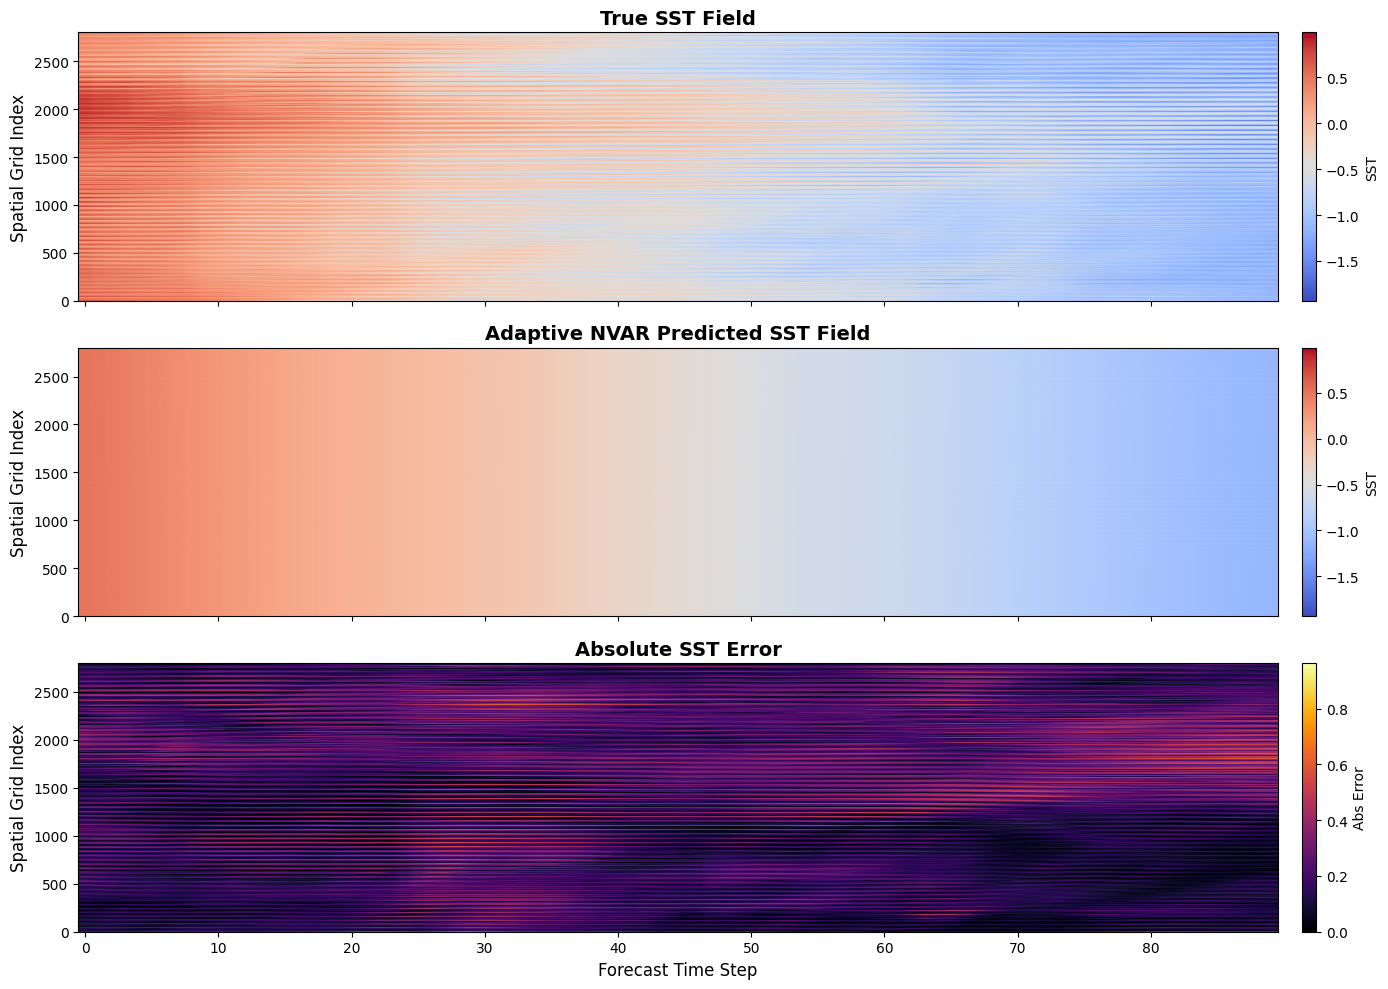

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. VARIABLE RESOLUTION & SETUP
# ============================================================
plot_len = 90    # Set forecast horizon to visualize
window_idx = 330  # 0 = first window, 1 = second, ...

# Fallback check to ensure data variables exist in memory
if 'y_test_rec_sst' in globals() and len(y_test_rec_sst) > 0:
    X_rec_norm = y_test_rec_sst
    X_test_true_raw = y_test_true_sst
elif 'all_test_rec_sst' in globals() and len(all_test_rec_sst) > 0:
    X_rec_norm = all_test_rec_sst[window_idx]
    X_test_true_raw = all_test_true_sst[window_idx]
else:
    raise NameError(
        "Evaluation data not found in memory! "
        "Please run your test evaluation loop first."
    )

# Slice arrays to the requested plot length
true_field = X_test_true_raw[:plot_len]
pred_field = X_rec_norm[:plot_len]

# ============================================================
# 2. ABSOLUTE ERROR & COLORMAP RANGES
# ============================================================
sst_error = np.abs(true_field - pred_field)

# Enforce shared color scale for True and Predicted fields
vmin_sst = min(true_field.min(), pred_field.min())
vmax_sst = max(true_field.max(), pred_field.max())

# ============================================================
# 3. SUBPLOTS SETUP
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# --- TRUE SST FIELD ---
im0 = axes[0].imshow(
    true_field.T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',
    vmin=vmin_sst,
    vmax=vmax_sst
)
axes[0].set_title('True SST Field', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Spatial Grid Index', fontsize=12)

# --- PREDICTED SST FIELD (3-Model Ensemble) ---
im1 = axes[1].imshow(
    pred_field.T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',
    vmin=vmin_sst,
    vmax=vmax_sst
)
axes[1].set_title('Adaptive NVAR Predicted SST Field', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Spatial Grid Index', fontsize=12)

# --- ABSOLUTE ERROR FIELD ---
im2 = axes[2].imshow(
    sst_error.T,
    aspect='auto',
    origin='lower',
    cmap='inferno',
    vmin=0,
    vmax=sst_error.max()
)
axes[2].set_title('Absolute SST Error', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Forecast Time Step', fontsize=12)
axes[2].set_ylabel('Spatial Grid Index', fontsize=12)

# ============================================================
# 4. COLORBARS & EXPORT
# ============================================================
cbar0 = fig.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)
cbar0.set_label('SST', fontsize=10)

cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)
cbar1.set_label('SST', fontsize=10)

cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.02, pad=0.02)
cbar2.set_label('Abs Error', fontsize=10)

plt.tight_layout()

plt.savefig(
    "adaptive_nvar_ensemble_sst_field_evolution_East_Sea.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()